# Data Science Lab on Smart Cities

## Decoding the Intersection between Ridesourcing Dependency and Socio-Demographic Vulnerability in the Chicago FUA

Research question: Is ridesourcing acting as a mobility equalizer or as a costly substitute for inadequate public transport in vulnerable peripheral areas of Chicago?

**Analysis flow**

1. Data sources
2. Transport Usage Index (TUI)
3. Socio-Demographic Vulnerability Index (SDVI)
4. TUI vs vulnerability (correlations and maps)
5. Weighted TUI (Financial Burden Index)
6. Ridesharing travel time to the Loop

## 1. Data Sources

- CMAP Community Data Snapshots — [ArcGIS FeatureServer](https://services5.arcgis.com/LcMXE3TFhi1BSaCY/arcgis/rest/services/CommunityDataSnapshots_2015_2025_gdb/FeatureServer) · [Data Hub](https://datahub.cmap.illinois.gov/search?tags=community%2520data%2520snapshots)
- Transportation Network Providers trips (Chicago Data Portal): [2018–2022](https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2018-2022-/m6dm-c72p/data_preview) · [2023–2024](https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2023-2024-/n26f-ihde/data_preview)
- Hardship Index and CCVI (Chicago Data Portal)
- Community Area boundaries — [Chicago Data Portal](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6)


In [2]:
# Install dependencies (skipped when already satisfied)
import subprocess
import sys

# PyPI backport shadows stdlib importlib on Python 3.13 and breaks pip
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "importlib"],
    capture_output=True,
)

%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import utils
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot

importlib.reload(utils)

from utils import (
    DEFAULT_AVG_TRIP_COST_USD,
    build_analysis_gdf,
    build_loop_travel_time_map,
    build_tui_map,
    build_weighted_tui_map,
    compute_tui_correlations,
    compute_weighted_tui,
    load_all_cca_population,
    load_chicago_community_areas,
    load_vulnerability_data,
    plot_loop_travel_time_map,
    plot_tui_index,
    plot_tui_vulnerability_maps,
    plot_tui_vulnerability_scatter,
    plot_weighted_tui_map,
    save_chart,
    source_loop_travel_times,
    source_tnp_counts,
    source_tnp_fares,
    compute_moran,
    plot_moran_scatterplot,
    compute_lisa,
    plot_lisa_map, 
    compute_transit_accessibility,
    plot_transit_deficit,
)

## 2. Transport Usage Index (TUI)

TNP Usage Intensity measures ridesourcing trips per 1,000 residents in Community Area $i$ during month $m$:

$$TUI_{i,m} = \frac{\text{TNP pickups}_{i,m}}{\text{population}_{i,m}} \times 1000$$

Higher values indicate more TNP activity per resident. The index reflects usage intensity, not dependency, unless combined with accessibility indicators.

In [4]:
url_2023_2024 = "https://data.cityofchicago.org/resource/n26f-ihde.json"
source_tnp_counts(url_2023_2024, "tnp_counts_2023-2024")

Using cached TNP data: data/tnp_counts_2023-2024.csv


PosixPath('data/tnp_counts_2023-2024.csv')

In [5]:
url_2018_2022 = "https://data.cityofchicago.org/resource/m6dm-c72p.json"
source_tnp_counts(url_2018_2022, "tnp_counts_2018-2022")

Using cached TNP data: data/tnp_counts_2018-2022.csv


PosixPath('data/tnp_counts_2018-2022.csv')

In [6]:
tnp_counts_2018_2022 = pd.read_csv("data/tnp_counts_2018-2022.csv")
tnp_counts_2023_2024 = pd.read_csv("data/tnp_counts_2023-2024.csv")
tnp_counts = pd.concat([tnp_counts_2018_2022, tnp_counts_2023_2024], ignore_index=True)
tnp_counts["month"] = pd.to_datetime(tnp_counts["month"])
tnp_counts["year"] = tnp_counts["month"].dt.year
tnp_counts = tnp_counts.rename(columns={"pickup_community_area": "community_area"})

population = load_all_cca_population("data")
df = pd.merge(tnp_counts, population, on=["community_area", "year"], how="left")

In [7]:
df["tui_index"] = (df["n_trips"] / df["population"]) * 1000

In [8]:
df.to_csv("data/tui_index.csv", index=False)
df.head()

,month,community_area,n_trips,year,community_area_name,population,tui_index
0,2018-11-01,1,99221,2018,Rogers Park,55500.0,1787.765766
1,2018-11-01,2,71955,2018,West Ridge,73723.0,976.018339
2,2018-11-01,3,187550,2018,Uptown,56296.0,3331.497797
3,2018-11-01,4,89958,2018,Lincoln Square,41483.0,2168.550973
4,2018-11-01,5,104623,2018,North Center,34942.0,2994.190373


In [9]:
tui = pd.read_csv("data/tui_index.csv", parse_dates=["month"])
chicago_community_areas = load_chicago_community_areas(
    "data/Boundaries_-_Community_Areas_20260607.geojson"
)

tui_map_2018 = build_tui_map(chicago_community_areas, tui, year=2018)
tui_map_2024 = build_tui_map(chicago_community_areas, tui, year=2024)

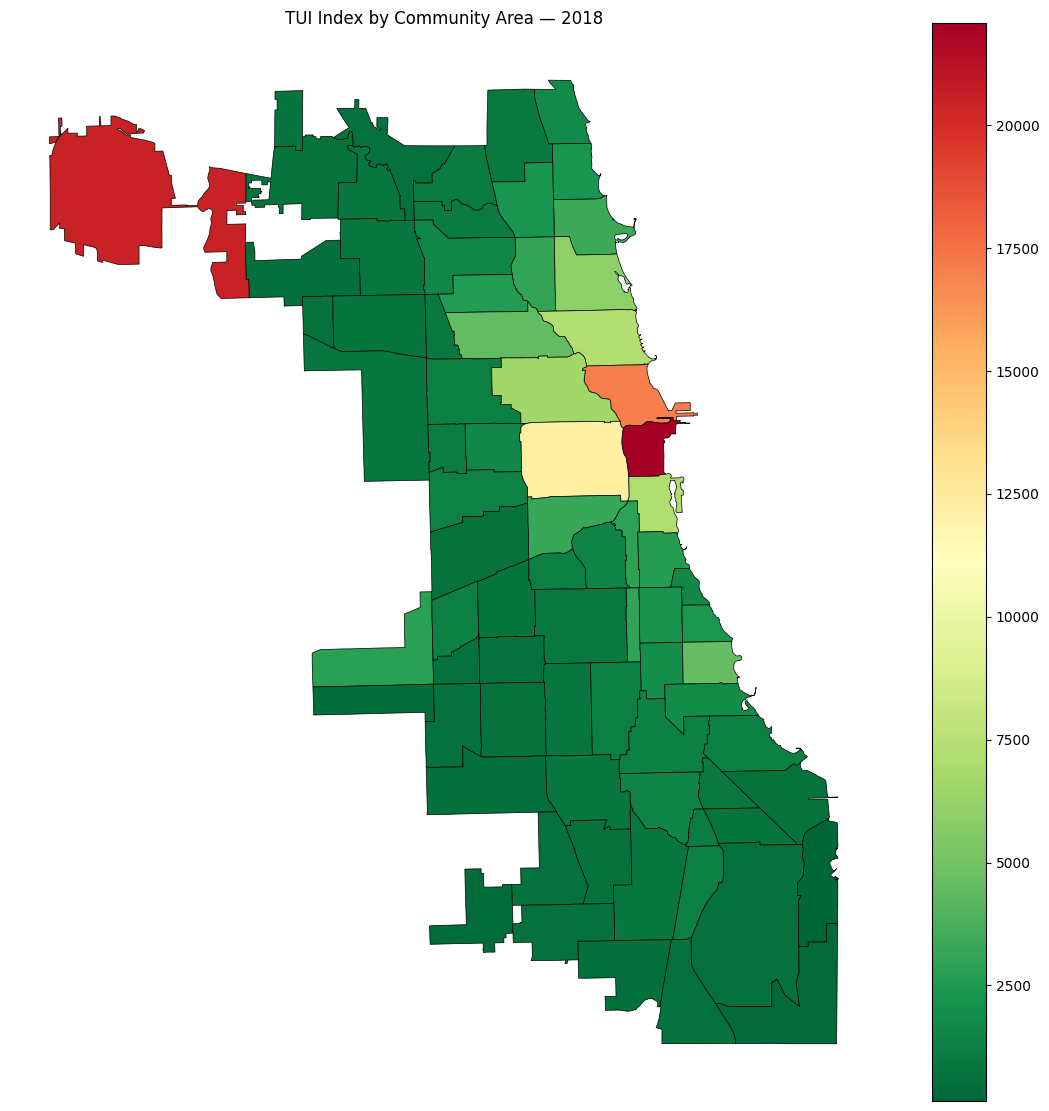

In [10]:
ax = plot_tui_index(tui_map_2018, year=2018, add_labels=False)
save_chart(ax, "tui_2018")
plt.show()

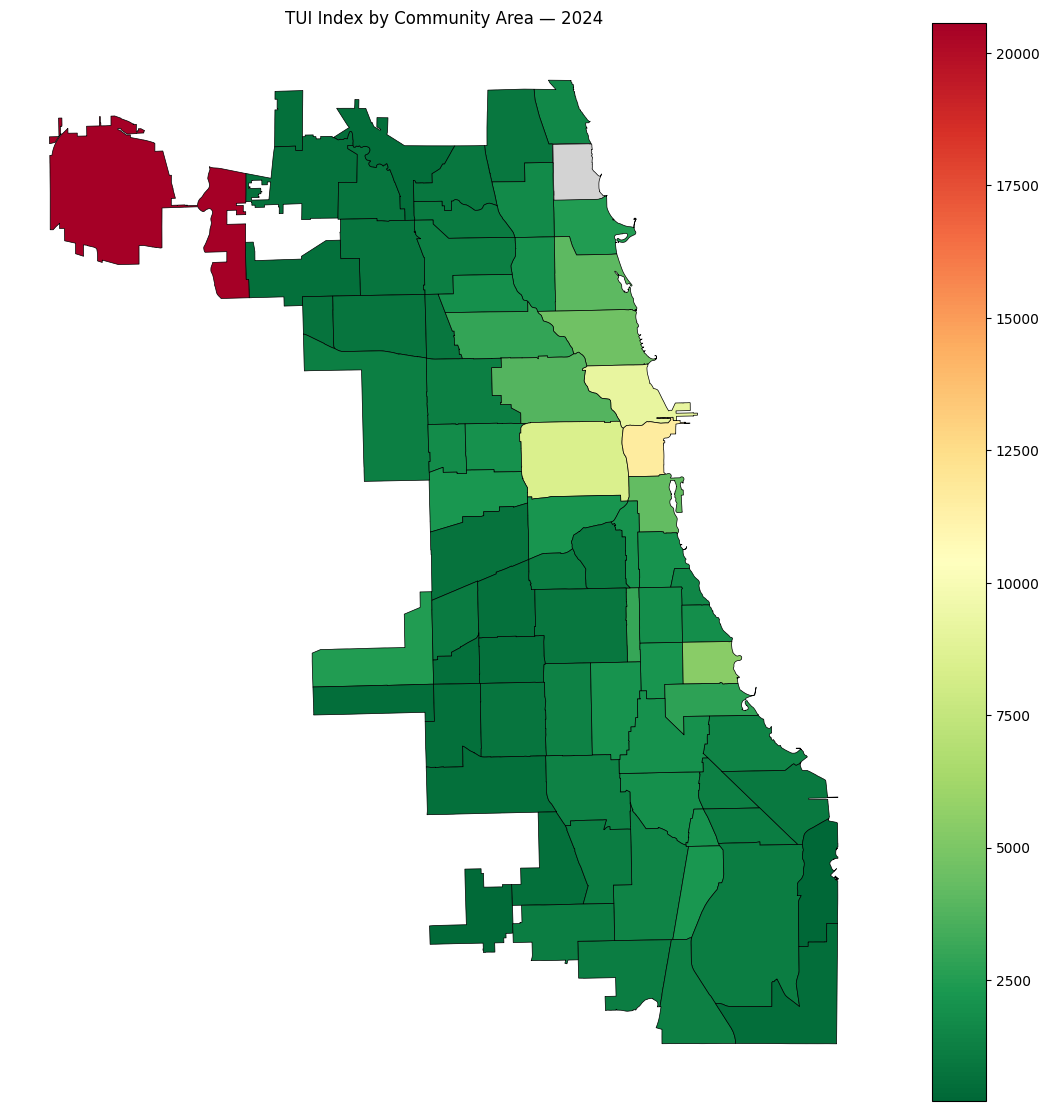

In [11]:
ax = plot_tui_index(tui_map_2024, year=2024, add_labels=False)
save_chart(ax, "tui_2024")
plt.show()

## 3. Socio-Demographic Vulnerability Index (SDVI)

Composite index combining **Hardship Index** and **per capita income** (income enters as disadvantage: lower income implies higher vulnerability). Higher SDVI values indicate greater socio-demographic vulnerability.

**HSVI** (baseline): `mean(z(Hardship), z(CCVI))`. **CCVI** is kept as an auxiliary health indicator.

Community Area 76 (O'Hare) is excluded from socio-demographic modelling.

In [12]:
vulnerability = load_vulnerability_data("data")
analysis_gdf = build_analysis_gdf(tui_map_2024, vulnerability)

print(f"Community Areas in analysis (excl. O'Hare): {len(analysis_gdf)}")
analysis_gdf[[
    "community_area", "community_area_name", "tui_index",
    "hardship_index", "per_capita_income", "hsvi", "sdvi", "ccvi_score",
]].head()

Community Areas in analysis (excl. O'Hare): 75


,community_area,community_area_name,tui_index,hardship_index,per_capita_income,hsvi,sdvi,ccvi_score
0,1,ROGERS PARK,1589.021917,39.0,23939,-0.426475,-0.129999,30.9
1,2,WEST RIDGE,872.629786,46.0,23040,-0.133205,0.021385,36.0
2,3,UPTOWN,2516.201448,20.0,35787,-0.975891,-0.848483,24.4
3,4,LINCOLN SQUARE,1680.655769,17.0,37524,-1.343862,-0.957555,15.0
4,5,NORTH CENTER,1983.218853,6.0,57123,-1.904987,-1.790035,4.0


### Morans I
Is ridesourcing intensity spatially clustered, or randomly distributed across Chicago?
If high-TUI areas are near other high-TUI areas, then TUI has a spatial structure.

Moran's I: 0.6115124492865796
p-value: 0.001


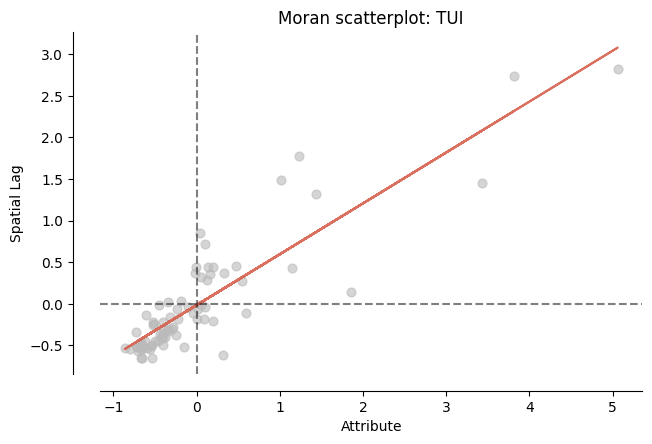

In [13]:
moran = compute_moran(analysis_gdf, "tui_index")
plot_moran_scatterplot(moran)

The Moran scatterplot shows a clear positive relationship between each Community Area’s TUI value and the average TUI of its neighbours, meaning that ridesourcing intensity is spatially clustered rather than randomly distributed: high-TUI areas tend to be near other high-TUI areas, and low-TUI areas tend to be near low-TUI areas.

### LISA
Is ridesourcing intensity spatially clustered, or randomly distributed across Chicago?
If high-TUI areas are near other high-TUI areas, then TUI has a spatial structure.

In [14]:

lisa, analysis_gdf = compute_lisa(analysis_gdf, "tui_index")

LISA computed.


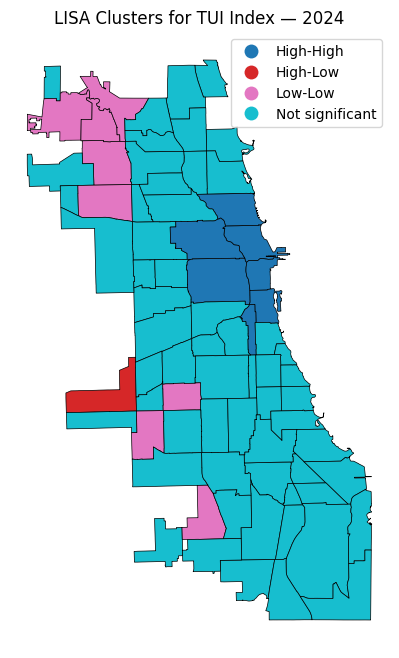

In [15]:
plot_lisa_map(analysis_gdf, 2024)

The LISA map localizes the pattern identified with Morans scatterplot: the blue High–High cluster identifies a core group of neighbouring areas with consistently high TUI, while the pink Low–Low clusters show areas where ridesourcing intensity is systematically low relative to surrounding areas; the red High–Low area is a spatial outlier with high TUI surrounded by lower-TUI neighbours.

## 4. TUI vs vulnerability

Pearson and Spearman correlations between mean TUI (2024) and HSVI, SDVI, and CCVI. Side-by-side choropleth maps compare spatial patterns.

=== Pearson ===


,tui_index,hsvi,sdvi,ccvi_score
tui_index,1.000,-0.472,-0.542,-0.515
hsvi,-0.472,1.000,0.957,0.950
sdvi,-0.542,0.957,1.000,0.857
ccvi_score,-0.515,0.950,0.857,1.000



=== Spearman ===


,tui_index,hsvi,sdvi,ccvi_score
tui_index,1.000,-0.174,-0.120,-0.255
hsvi,-0.174,1.000,0.960,0.925
sdvi,-0.120,0.960,1.000,0.797
ccvi_score,-0.255,0.925,0.797,1.000


TUI vs HSVI: r=-0.472 (p=0.0000), rho=-0.174 (p=0.1344)
TUI vs SDVI: r=-0.542 (p=0.0000), rho=-0.120 (p=0.3061)
TUI vs CCVI: r=-0.515 (p=0.0000), rho=-0.255 (p=0.0274)


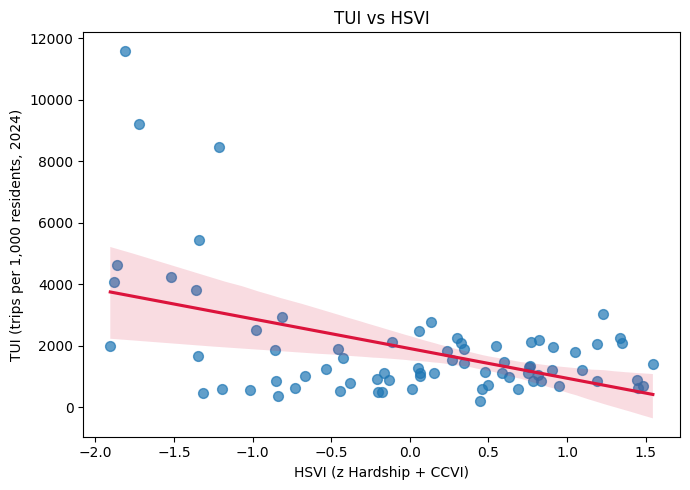

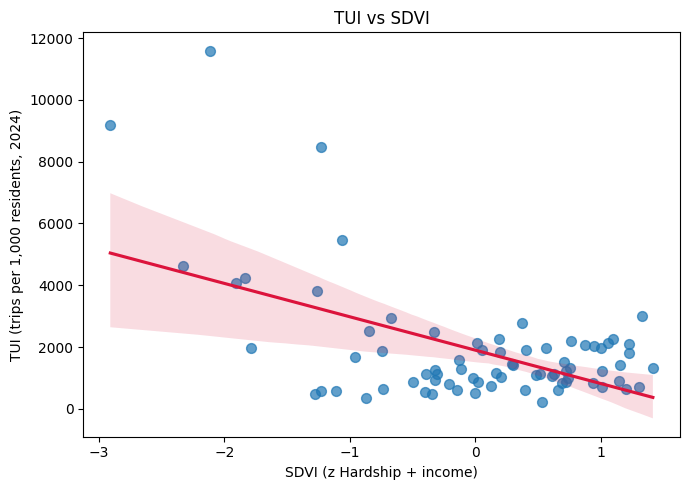

In [16]:
pearson, spearman, tests = compute_tui_correlations(analysis_gdf)

print("=== Pearson ===")
display(pearson.round(3))
print("\n=== Spearman ===")
display(spearman.round(3))

for _, row in tests.iterrows():
    print(
        f"TUI vs {row['indicator']}: "
        f"r={row['pearson_r']:.3f} (p={row['pearson_p']:.4f}), "
        f"rho={row['spearman_rho']:.3f} (p={row['spearman_p']:.4f})"
    )

ax = plot_tui_vulnerability_scatter(analysis_gdf, x="hsvi", year=2024)
save_chart(ax, "tui_vs_hsvi_2024")
plt.tight_layout()
plt.show()

ax = plot_tui_vulnerability_scatter(analysis_gdf, x="sdvi", year=2024)
save_chart(ax, "tui_vs_sdvi_2024")
plt.tight_layout()
plt.show()

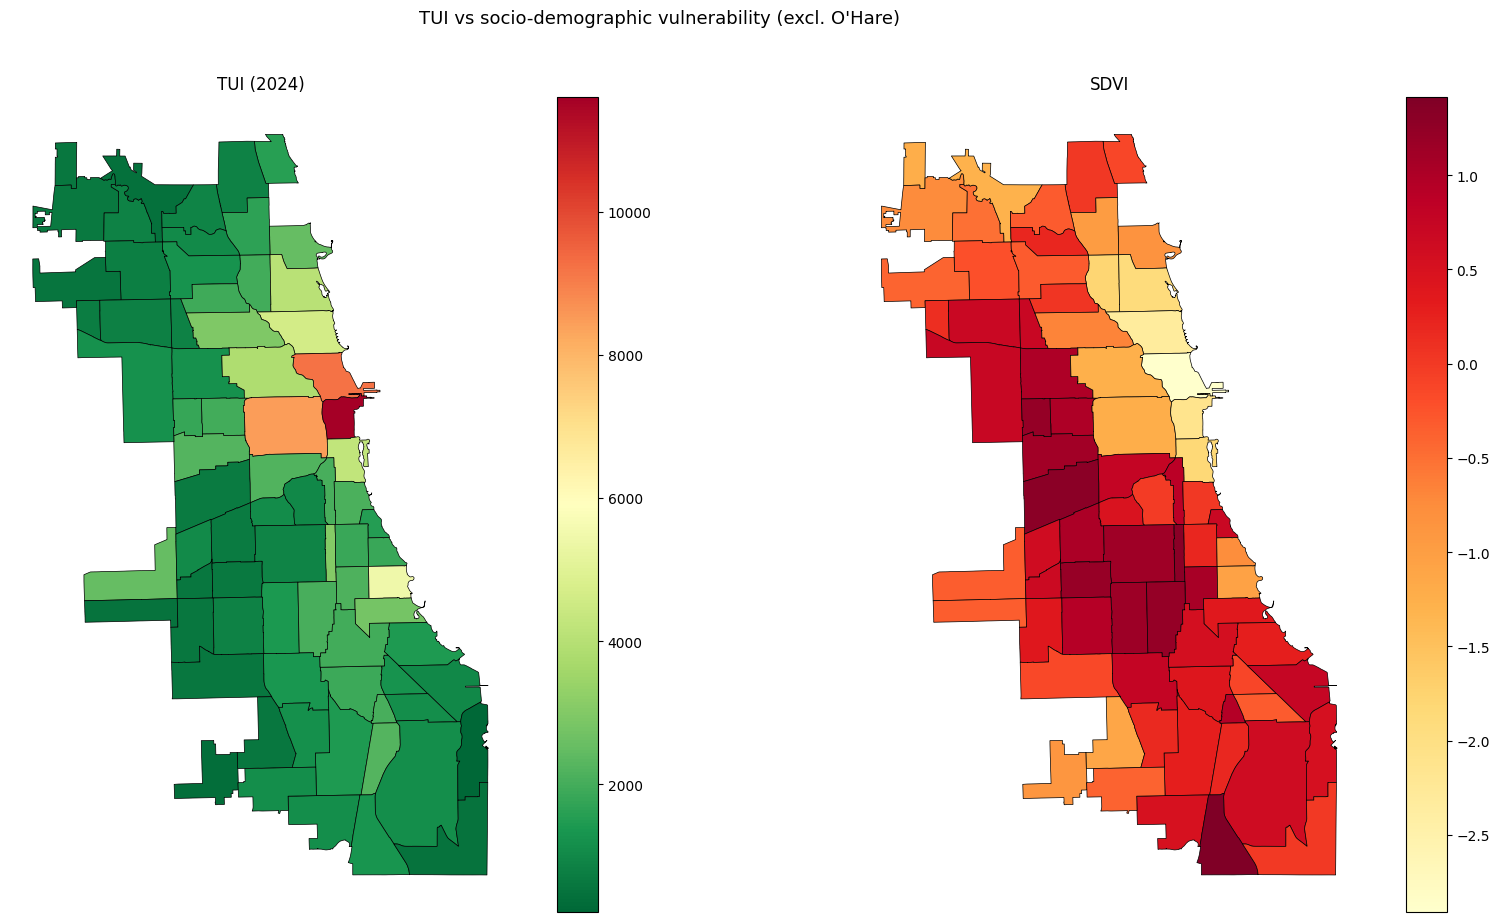

In [17]:
fig = plot_tui_vulnerability_maps(analysis_gdf, year=2024)
save_chart(fig, "tui_sdvi_maps_2024")
plt.show()

## 5. Weighted TUI (Financial Burden Index)

Estimates ridesharing financial burden per Community Area:

$$\text{total\_spend}_i = \text{n\_trips}_i \times \text{avg\_trip\_cost}_i$$
$$\text{rideshare\_spend\_pc}_i = \frac{\text{total\_spend}_i}{\text{population}_i}$$
$$\text{Weighted\_TUI}_i = \frac{\text{rideshare\_spend\_pc}_i}{\text{per\_capita\_income}_i}$$

Trip counts come from aggregated TNP data; a uniform mean trip cost proxy is applied because fare is not available in the count files. O'Hare (CA 76) excluded.

In [18]:
median_trip_cost_2023_2024 = source_tnp_fares(url_2023_2024, "tnp_median_fares_2023_2024", force=False)

Using cached TNP data: data/tnp_median_fares_2023_2024.csv


,community_area,n_trips,total_spend,rideshare_spend_pc,per_capita_income,Weighted_TUI
36,37,6703,90691.59,40.862934,10432,0.003917
55,56,90680,3512036.40,96.481866,26353,0.003661
27,28,554909,9344667.56,142.490471,44689,0.003188
31,32,483198,8687900.04,208.487918,65526,0.003182
53,54,10298,175992.82,22.514113,8201,0.002745
28,29,68687,978789.75,32.187502,12034,0.002675
67,68,44502,624808.08,29.226685,11888,0.002459
46,47,4598,68142.36,30.339430,12515,0.002424
39,40,26419,391001.20,31.619052,13785,0.002294
25,26,29319,402549.87,24.584700,10934,0.002248


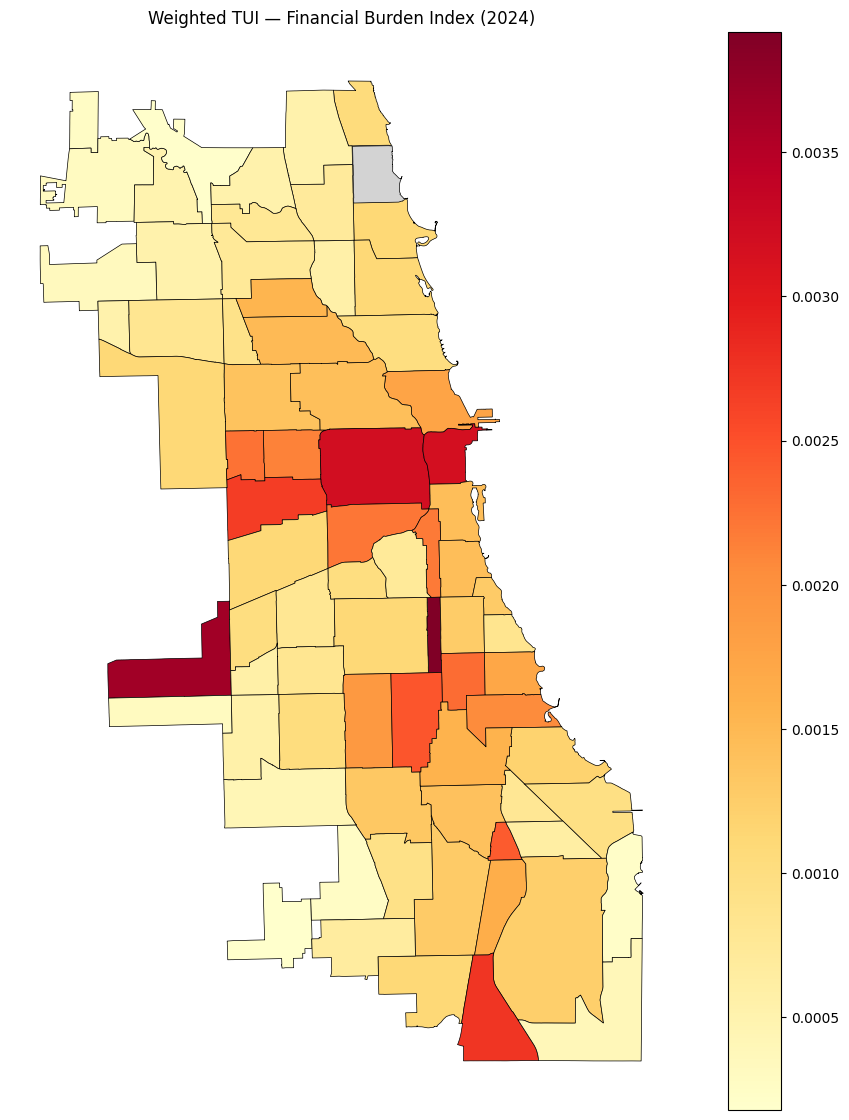

In [19]:
weighted_tui_df = compute_weighted_tui(
    df,
    vulnerability,
    median_trip_cost_2023_2024,
    year=2024,   
)
weighted_tui_map = build_weighted_tui_map(chicago_community_areas, weighted_tui_df)

display(
    weighted_tui_df[
        ["community_area", "n_trips", "total_spend", "rideshare_spend_pc", "per_capita_income", "Weighted_TUI"]
    ].sort_values("Weighted_TUI", ascending=False).head(10)
)

ax = plot_weighted_tui_map(weighted_tui_map, year=2024)
save_chart(ax, "weighted_tui_2024")
plt.show()

## 6. Ridesharing travel time to the Loop

Mean `trip_seconds` for TNP trips with **dropoff Community Area 32** (Loop), grouped by pickup Community Area. O'Hare (CA 76) excluded from origins. Values are aggregated from the trip-level TNP API (monthly queries, cached locally).

Using cached loop travel times: data/tnp_loop_travel_times_2024.csv


,community_area,mean_trip_seconds,n_trips,mean_trip_minutes
8,9,2564.749049,1052.0,42.745817
9,10,2444.581327,5441.0,40.743022
16,17,2297.853565,5470.0,38.297559
17,18,2296.387332,1784.0,38.273122
73,74,2296.312925,1029.0,38.271882
69,70,2277.188963,5255.0,37.953149
54,55,2263.016393,1037.0,37.716940
11,12,2192.315251,3226.0,36.538588
12,13,2128.041418,5022.0,35.467357
53,54,2059.400742,1078.0,34.323346


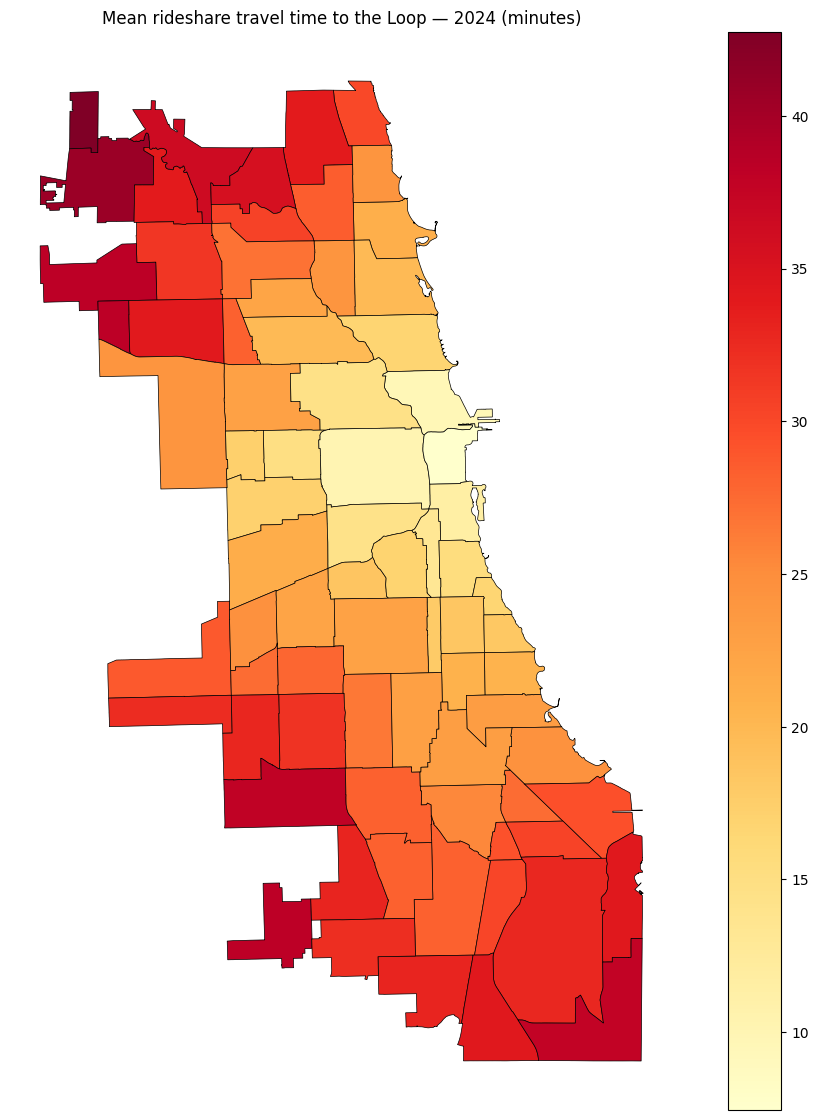

In [20]:
source_loop_travel_times(url_2023_2024, "tnp_loop_travel_times_2024", year=2024)
loop_travel_df = pd.read_csv("data/tnp_loop_travel_times_2024.csv")
loop_travel_df["community_area"] = loop_travel_df["community_area"].astype(int)

loop_travel_map = build_loop_travel_time_map(chicago_community_areas, loop_travel_df)
loop_travel_map["mean_trip_minutes"] = loop_travel_map["mean_trip_seconds"] / 60

display(
    loop_travel_df.assign(mean_trip_minutes=loop_travel_df["mean_trip_seconds"] / 60)
    .sort_values("mean_trip_seconds", ascending=False)
    .head(10)
)

ax = plot_loop_travel_time_map(loop_travel_map, year=2024)
save_chart(ax, "loop_travel_time_2024")
plt.show()

## 7. Transit Accessibility Index (physical supply density)
It measures how many CTA bus stops and rail stations are available within each Community Area, normalized by area size. Higher values mean better physical transit supply; the inverse standardized value gives the Transit Deficit Index.

### Transit Accessibility Index

For each Community Area \(i\), we first calculate the density of CTA bus stops and rail stations:

- $BusDensity_i = \frac{N^{bus}_i}{Area_i}$

- $RailDensity_i = \frac{N^{rail}_i}{Area_i}$

where $N^{bus}_i$ is the number of CTA bus stops in Community Area i, $N^{rail}_i$ is the number of CTA rail stations in Community Area i, and $Area_i$ is the area of the Community Area in square kilometers.

Each density variable is then standardized using a z-score.


The **Transit Accessibility Index** is defined as the average of the standardized bus and rail access measures:

- $TransitAccess_i =
\frac{
z(BusDensity_i) + z(RailDensity_i)
}{2}$

The **Transit Deficit Index** is defined as the negative standardized Transit Accessibility Index:

- $TransitDeficit_i = -z(TransitAccess_i)$

Higher values of \(TransitDeficit_i\) indicate weaker physical access to CTA infrastructure, while lower values indicate better-than-average transit accessibility.

In [21]:
transit = compute_transit_accessibility(
    community_areas=chicago_community_areas,
    bus_path="data/CTA_BusStops/CTA_BusStops.shp",
    rail_path="data/CTA_-_'L'_(Rail)_Stations_20260630.geojson"
)

transit.drop(columns="geometry").to_csv("data/transit_accessibility_index.csv", index=False)

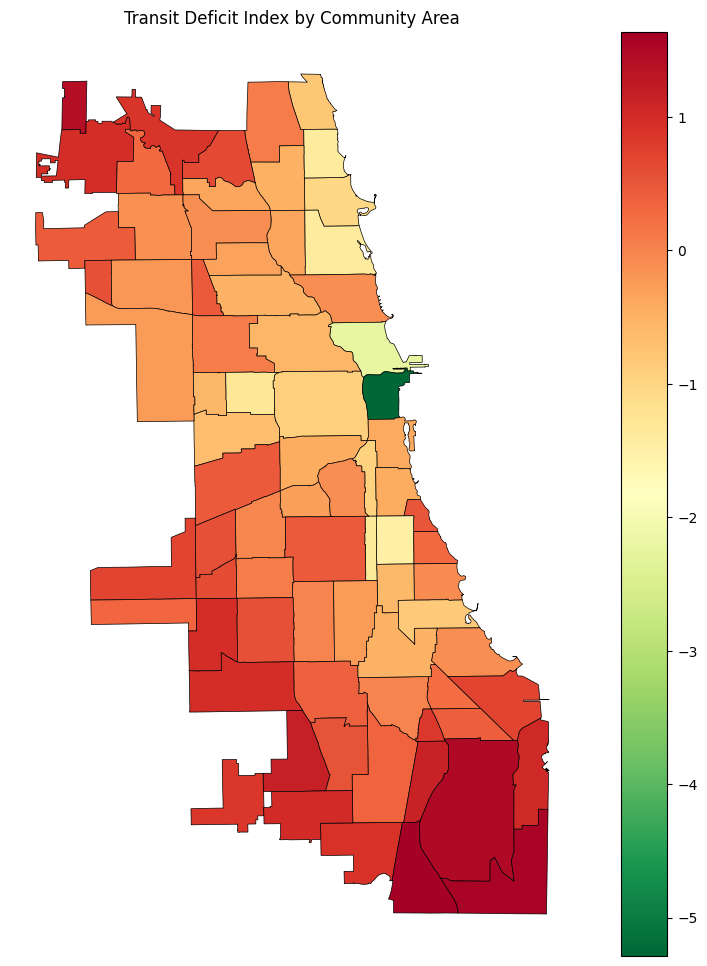

In [22]:
plot_transit_deficit(transit)

Red areas have higher transit deficit, meaning fewer CTA bus stops / rail stations per km² relative to the city average. Green areas have lower transit deficit, meaning better physical transit accessibility.

The strong green area corresponding to the Loop is expected because CTA rail and bus infrastructure is dense there.

In [ ]:
# least accessible areas
transit[
    ["community_area", "community_area_name", "n_bus_stops", "n_rail_stations",
     "bus_stops_per_km2", "rail_stations_per_km2", "transit_deficit"]
].sort_values("transit_deficit", ascending=False).head(10)

,community_area,community_area_name,n_bus_stops,n_rail_stations,bus_stops_per_km2,rail_stations_per_km2,transit_deficit
53,54,RIVERDALE,23,0.0,2.518175,0.000000,1.637340
54,55,HEGEWISCH,47,0.0,3.468684,0.000000,1.558411
50,51,SOUTH DEERING,121,0.0,4.290570,0.000000,1.490163
8,9,EDISON PARK,16,0.0,5.447528,0.000000,1.394090
71,72,BEVERLY,68,0.0,8.250672,0.000000,1.161320
49,50,PULLMAN,47,0.0,8.581081,0.000000,1.133883
51,52,EAST SIDE,74,0.0,9.576587,0.000000,1.051218
74,75,MORGAN PARK,88,0.0,10.317344,0.000000,0.989706
64,65,WEST LAWN,79,0.0,10.337815,0.000000,0.988006
9,10,NORWOOD PARK,104,1.0,9.185155,0.088319,0.984443


In [ ]:
# most accessible areas
transit[
    ["community_area", "community_area_name", "n_bus_stops", "n_rail_stations",
     "bus_stops_per_km2", "rail_stations_per_km2", "transit_deficit"]
].sort_values("transit_deficit").head(10)

,community_area,community_area_name,n_bus_stops,n_rail_stations,bus_stops_per_km2,rail_stations_per_km2,transit_deficit
31,32,LOOP,153,16.0,35.569621,3.719699,-5.288510
7,8,NEAR NORTH SIDE,254,7.0,35.684164,0.983422,-2.222186
37,38,GRAND BOULEVARD,126,4.0,27.989792,0.888565,-1.476625
5,6,LAKE VIEW,220,7.0,27.172445,0.864578,-1.381790
76,77,EDGEWATER,120,4.0,26.679784,0.889326,-1.368699
36,37,FULLER PARK,44,2.0,23.797759,1.081716,-1.345644
26,27,EAST GARFIELD PARK,136,4.0,27.187657,0.799637,-1.310054
2,3,UPTOWN,169,3.0,27.966043,0.496439,-1.033866
33,34,ARMOUR SQUARE,60,2.0,23.277451,0.775915,-0.958689
27,28,NEAR WEST SIDE,357,10.0,24.263550,0.679651,-0.932364
